Fold 1


C:\Users\sneha\AppData\Local\Temp\ipykernel_21364\438459472.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["card type"] = df["card type"].replace("xxx", "joker")


Fold 1 Accuracy: 0.8443
Fold 2
Fold 2 Accuracy: 0.8412
Fold 3
Fold 3 Accuracy: 0.8479
Fold 4
Fold 4 Accuracy: 0.8608
Fold 5
Fold 5 Accuracy: 0.7554

Average 5-Fold Accuracy: 0.8299016373710284


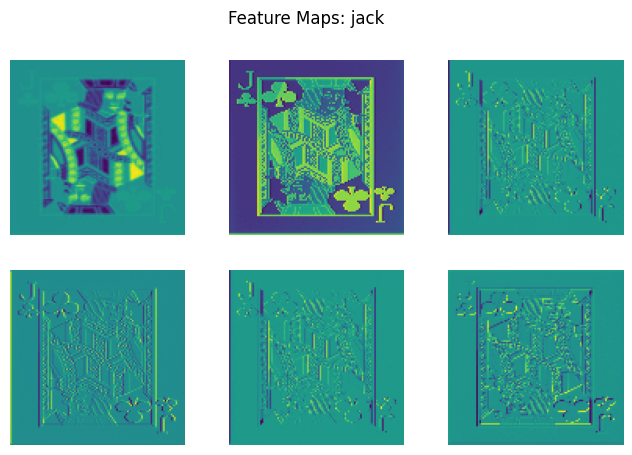

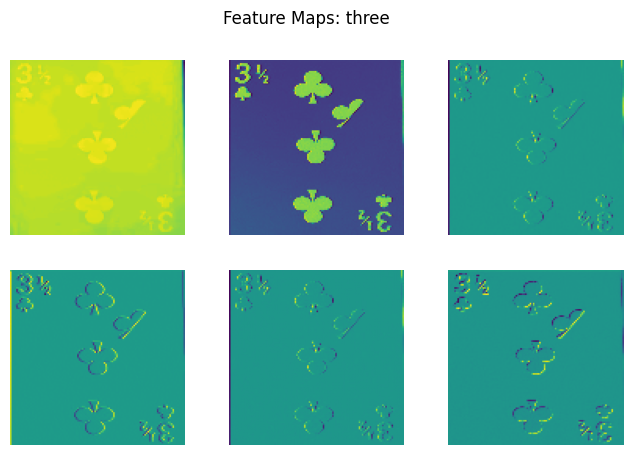

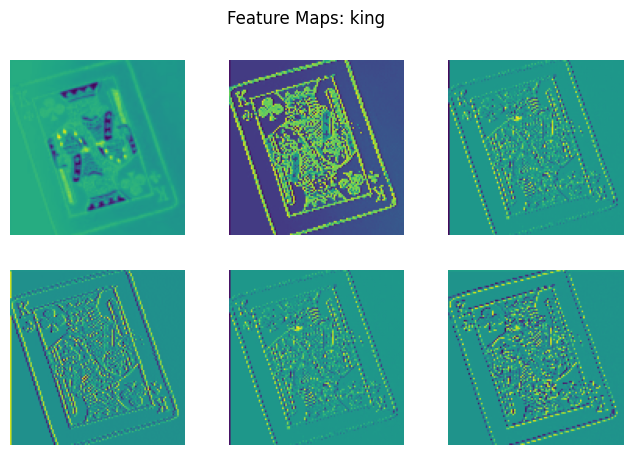

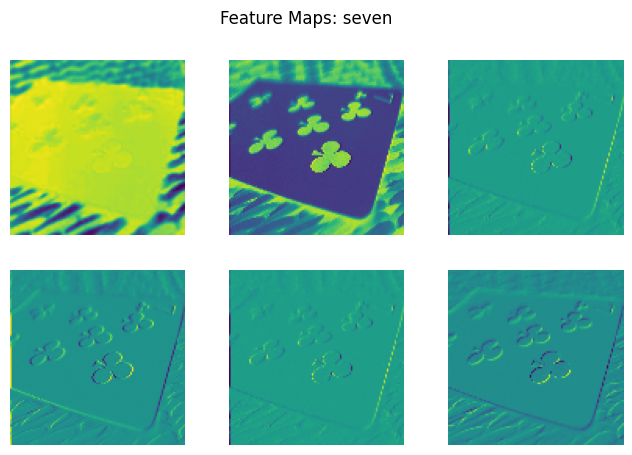

In [4]:
import pandas as pd
import numpy as np
from PIL import Image
from sklearn.model_selection import KFold
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

# dataset class
class CardDataset(Dataset):
    def __init__(self, df, transform=None):
        # there was one line in the file that had an invalid file path? I just removed it.
        df = df[~df["filepaths"].str.strip().str.endswith("output")]

        # remapped the "xxx" rank to "joker" for simplicity
        df["card type"] = df["card type"].replace("xxx", "joker")

        self.df = df.reset_index(drop=True)
        self.transform = transform
        
        # defines classes
        self.classes = sorted(self.df["card type"].unique())
        self.class_to_idx = {c: i for i, c in enumerate(self.classes)}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["filepaths"]).convert("RGB")
        label = self.class_to_idx[row["card type"]] # convert label name to integer
        if self.transform:
            img = self.transform(img)
        return img, label # returns tensor, int pair

# mobilenetv2
def get_model(num_classes):
    model = models.mobilenet_v2(weights="MobileNet_V2_Weights.DEFAULT")
    model.classifier[1] = nn.Linear(1280, num_classes)
    return model

# training one fold at a time
def train_one_fold(model, train_loader, val_loader, device):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-4)
    model.to(device)

    for epoch in range(2):  # I tried to do more but took way too long to run
        model.train()
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            loss = criterion(model(imgs), labels)
            loss.backward()
            optimizer.step()

    # validation
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            preds = model(imgs).argmax(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return correct / total, model

# feature map visualizations
def visualize_feature_maps(model, dataset, classname, n_images=1):
    subset = dataset.df[dataset.df["card type"] == classname].head(n_images)
    imgs = [Image.open(fp).convert("RGB") for fp in subset["filepaths"]]

    tf = transforms.Compose([
        transforms.Resize((224,224)),
        transforms.ToTensor()
    ])

    first_layer = model.features[0][0]
    activations = []

    def hook_fn(m, i, o):
        activations.append(o.detach().cpu())

    hook = first_layer.register_forward_hook(hook_fn)

    for img in imgs:
        model(tf(img).unsqueeze(0))
        act = activations[-1][0]

        fig, axs = plt.subplots(2, 3, figsize=(8, 5))
        for i, ax in enumerate(axs.flatten()):
            ax.imshow(act[i], cmap="viridis")
            ax.axis("off")
        plt.suptitle(f"Feature Maps: {classname}")
        plt.show()

    hook.remove()

# all of the main code
df = pd.read_csv("cards.csv")
device = "cpu"

# resize model input and convert to tensor
train_tf = transforms.Compose([
    transforms.Resize((224,224)),

    # data augmentation
    # this makes the most sense because some of the images were rotated in the training data and the colors can vary slightly
    # note: removed because it made the accuracy worse
    
    # transforms.RandomRotation(10),
    # transforms.ColorJitter(
    #     brightness=0.2, contrast=0.2,
    #     saturation=0.2, hue=0.02
    # ),
    
    transforms.ToTensor(),
])

val_tf = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
])


# sets up the 5 fold cross validation
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
fold = 1
all_acc = []

"""
1. for each fold, create CardDataset for training and validation using the rows of the original Dataframe.
2. wrap datasets in dataloader for batching
3. create MobileNetV2 with final lzyer sized for the classes in the training fold
4. Train the fold and get accuracy and the trained model back
"""
for train_idx, val_idx in kfold.split(df):
    print(f"Fold {fold}")

    train_ds = CardDataset(df.iloc[train_idx], transform=train_tf)
    val_ds   = CardDataset(df.iloc[val_idx],   transform=val_tf)

    train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
    val_loader   = DataLoader(val_ds, batch_size=32)

    model = get_model(num_classes=len(train_ds.classes))
    acc, trained_model = train_one_fold(model, train_loader, val_loader, device)

    print(f"Fold {fold} Accuracy: {acc:.4f}")
    all_acc.append(acc) 
    fold += 1

print("\nAverage 5-Fold Accuracy:", np.mean(all_acc))

# Feature maps for 2 face + 2 number
target_cards = ["jack", "three", "king", "seven"]
full_ds = CardDataset(df, transform=val_tf)

for c in target_cards:
    visualize_feature_maps(trained_model, full_ds, c)


#### Results:
I got an overall accuracy of 0.83, which doesn't quite meet the 90% mark. For data augmentation, I tried to account for rotation and color variation. However, this lowered the accuracy to 0.77